# Trabajo Práctico 4 - Aprendizaje Automático y Aprendizaje Profundo
**Nombre:** Eliana Ostrovsky  
**Materia:** I302 - Aprendizaje Automático y Aprendizaje Profundo  
**Objetivo:** Aplicar y comparar algoritmos de clustering y técnicas de reducción de dimensionalidad utilizando datasets provistos.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from src.KMeans import KMeans
from src.GMM import GMM
from src.DBSCAN import DBSCAN
from src.PCA import *
from src.utils.clustering_analysis import *
from src.utils.data_utils import *
from src.utils.pca_visualization import *
from src.utils.visualization import *

## 1. Clustering de datos

En esta sección se exploran distintos algoritmos de agrupamiento sobre un conjunto de datos bidimensional.

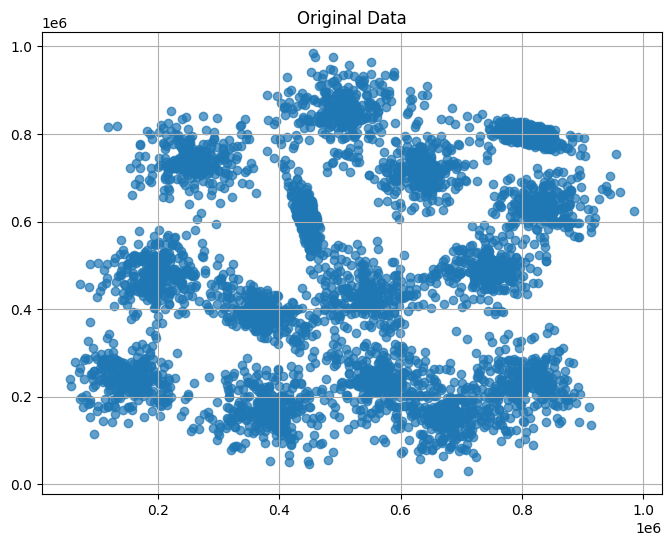

In [3]:
X_clust = pd.read_csv('data/clustering.csv').drop(columns=['Unnamed: 0']).values
plot_clusters(X_clust, np.ones(X_clust.shape[0]), title="Original Data")

### 1.a - K-means

Implementamos el algoritmo de K-means sobre el dataset `clustering.csv`.  
Seleccionamos el número óptimo de clusters utilizando el método del codo (gráfico L vs. K).


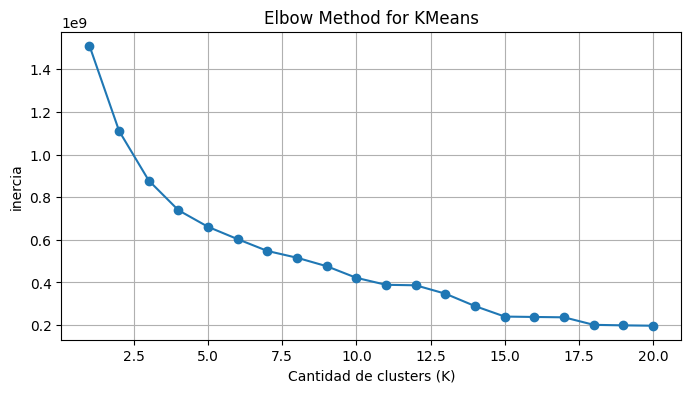

In [4]:
losses = elbow_method(X_clust, range(1, 21), KMeans, random_state=42)
_ = plot_elbow(losses, range(1, 21), title="Elbow Method for KMeans")

In [5]:
k_opt = 15
random_seed = fit_random_seed(KMeans, X_clust, k_opt)
kmeans = KMeans(n_clusters=k_opt, random_state=random_seed)
kmeans.fit(X_clust)

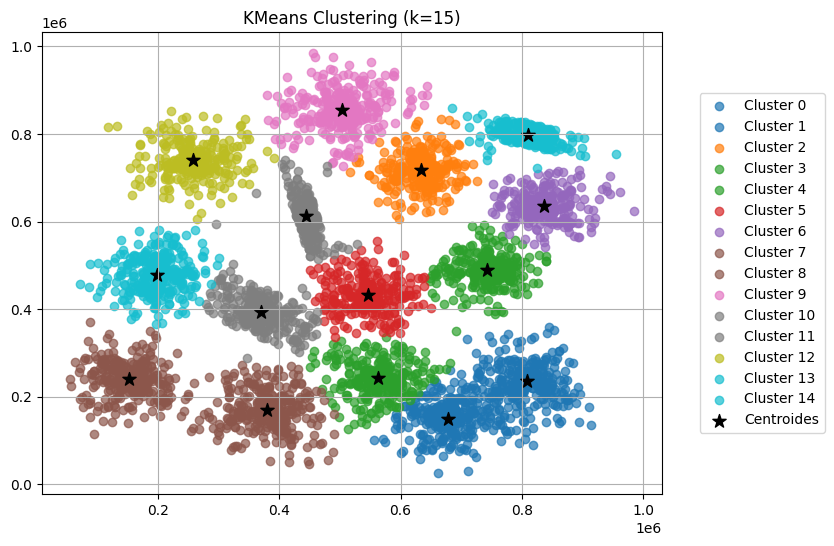

In [6]:
plot_clusters(X_clust, kmeans.predict(X_clust), centroids=kmeans.means_, title=f"KMeans Clustering (k={k_opt})")

### 1.b - Gaussian Mixture Models (GMM)

Aplicamos el algoritmo GMM utilizando inicialización con K-means.  
Se comparan visualmente los clusters y centros obtenidos con los de K-means.


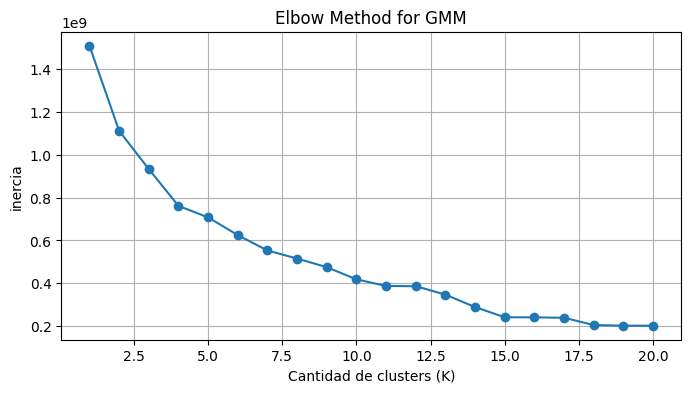

In [7]:
losses = elbow_method(X_clust, range(1, 21), GMM, random_state=42)
_ = plot_elbow(losses, range(1, 21), title="Elbow Method for GMM")

In [8]:
gmm = GMM(n_clusters=k_opt, random_state=random_seed)
gmm.fit(X_clust)

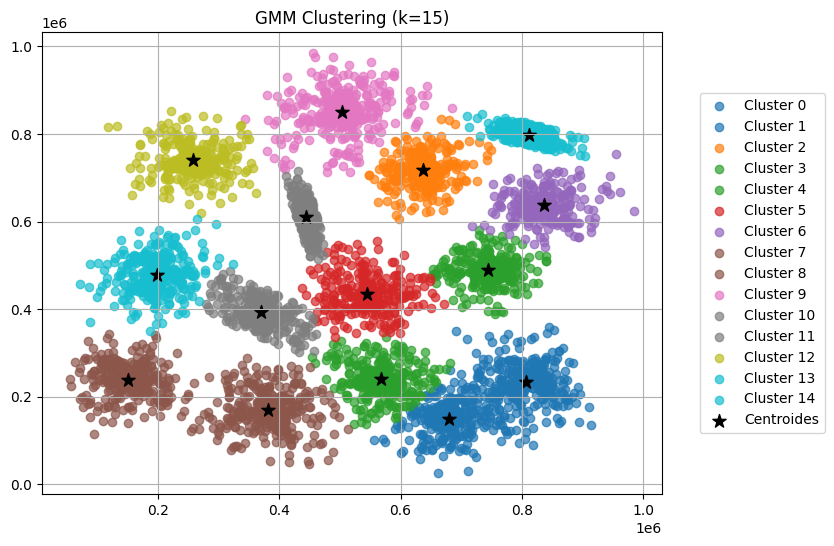

In [9]:
plot_clusters(X_clust, gmm.predict(X_clust), centroids=gmm.means_, title=f"GMM Clustering (k={k_opt})")

### 1.c - DBSCAN

Aplicamos DBSCAN al dataset.  
Se explora el efecto de variar los parámetros `ϵ` y `min_samples`.  
Se selecciona una configuración razonable y se grafican los clusters encontrados.


Evaluando DBSCAN...: 100%|██████████| 16/16 [00:24<00:00,  1.54s/it]

Mejores parámetros: eps=27500, min_samples=30 con silhouette=0.599


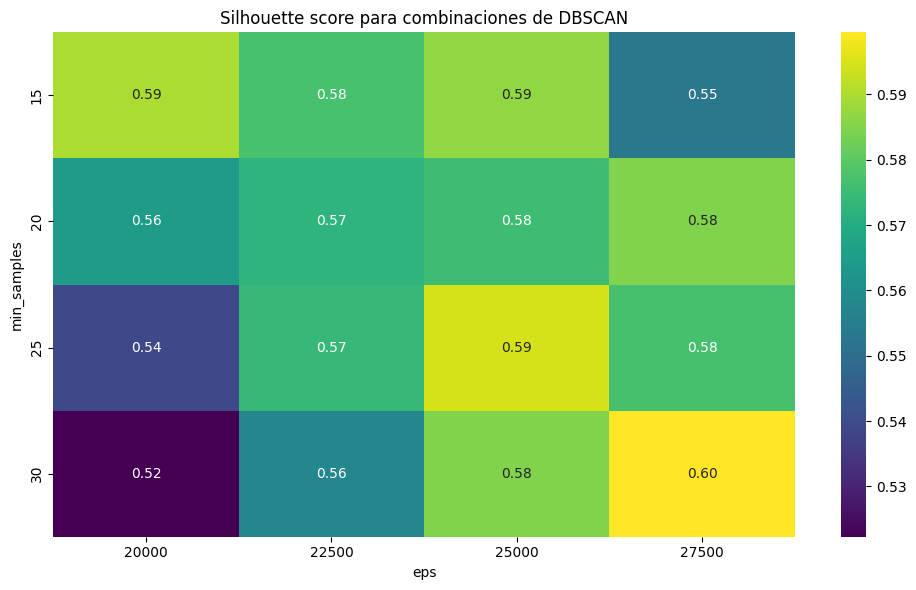

In [10]:
eps_values = [20000, 22500, 25000, 27500]
min_pts_values = [15, 20, 25, 30]
scores, best_params = explore_dbscan_params(X_clust, eps_values, min_pts_values)
plot_dbscan_scores(scores)

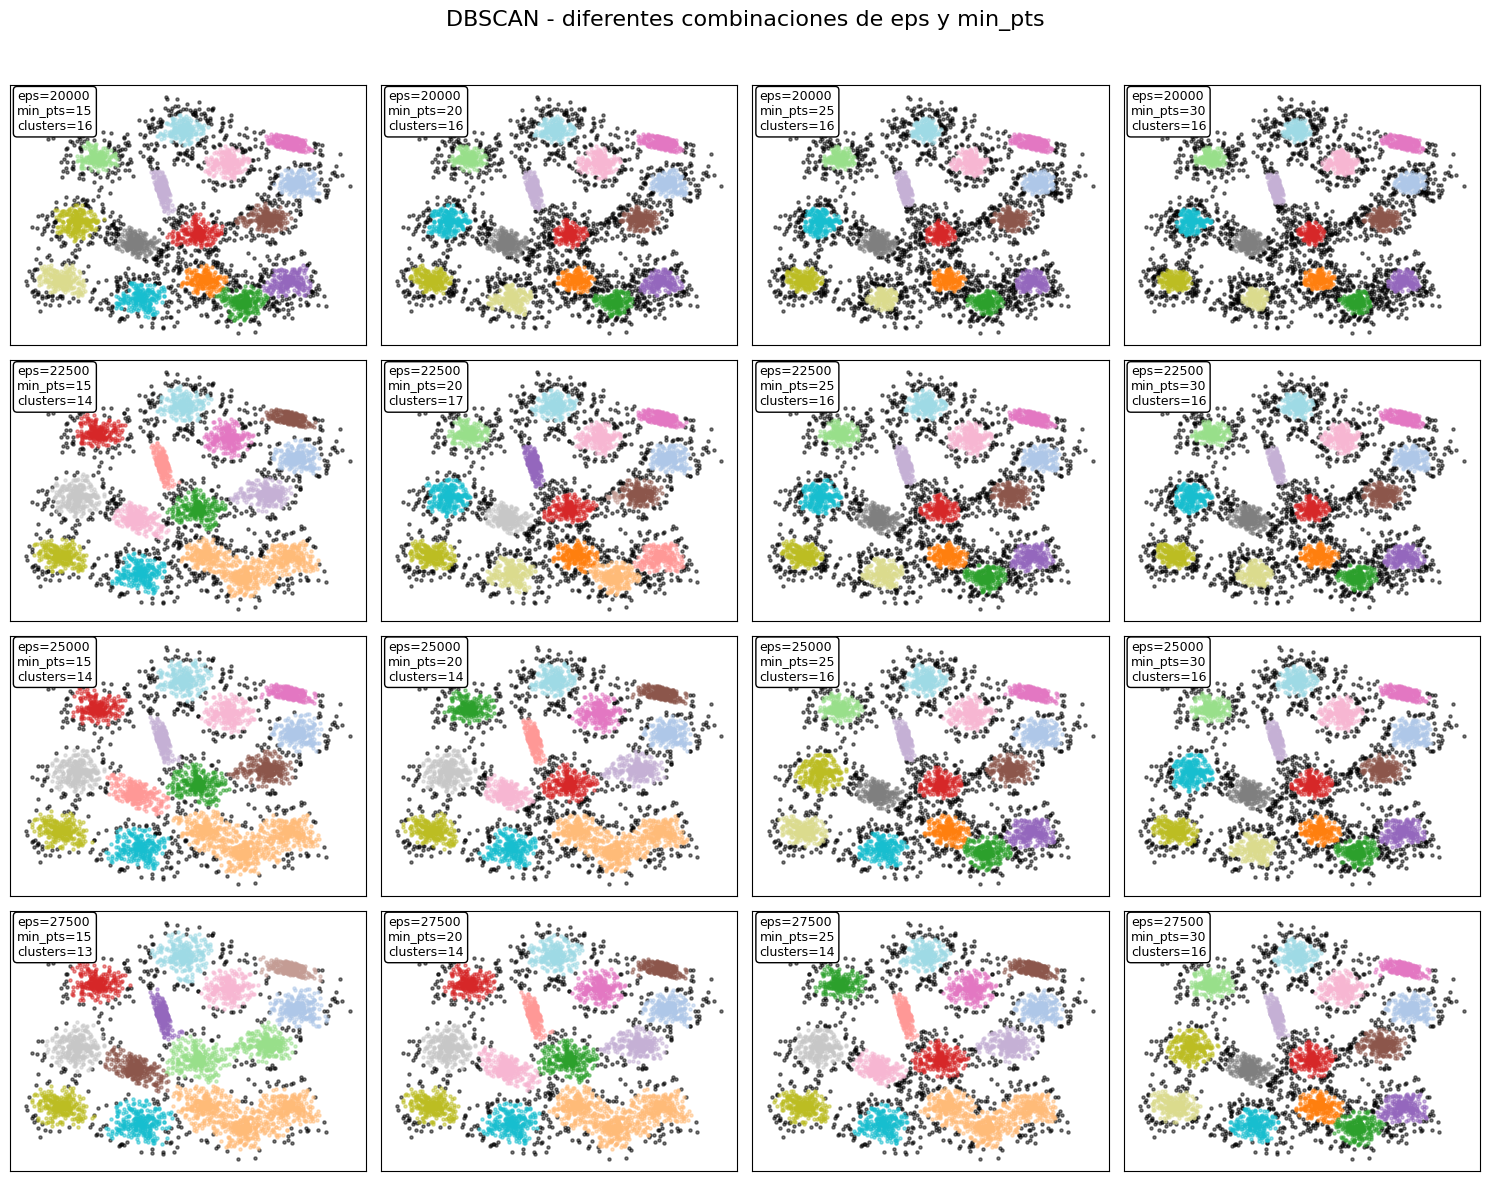

In [11]:
fig, axs = plt.subplots(len(eps_values), len(min_pts_values), figsize=(15, 12))
fig.suptitle("DBSCAN - diferentes combinaciones de eps y min_pts", fontsize=16)

for i, eps in enumerate(eps_values):
    for j, min_pts in enumerate(min_pts_values):
        model = DBSCAN(eps, min_pts)
        model.fit(X_clust)
        etiquetas = model.labels_
        etiquetas_unicas = np.unique(etiquetas)
        colores = plt.cm.tab20(np.linspace(0, 1, len(etiquetas_unicas)))

        ax = axs[i, j]
        for k, etiqueta in enumerate(etiquetas_unicas):
            puntos = X_clust[etiquetas == etiqueta]
            color = 'black' if etiqueta == -1 else colores[k % len(colores)]
            ax.scatter(puntos[:, 0], puntos[:, 1], color=color, s=5, alpha=0.5)

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.text(
            0.02, 0.98,
            f"eps={eps}\nmin_pts={min_pts}\nclusters={len(etiquetas_unicas)}",
            transform=ax.transAxes,
            fontsize=9,
            verticalalignment='top',
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3')
        )

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


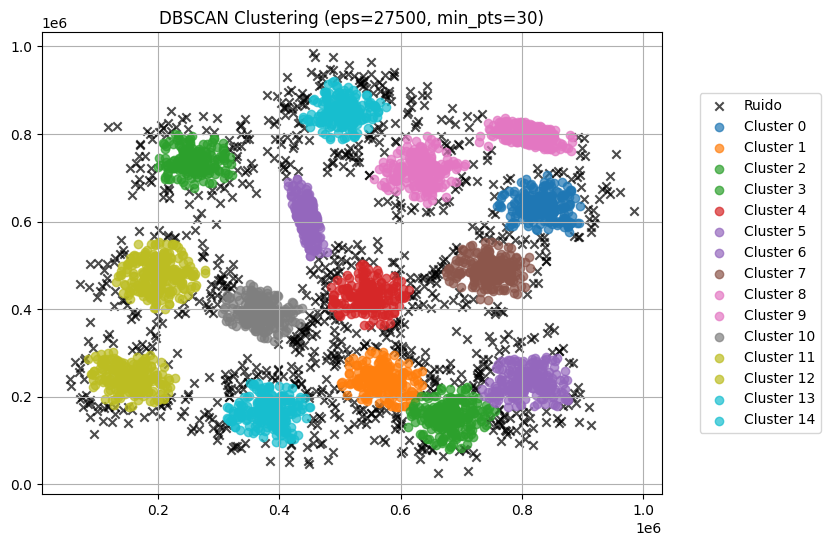

In [12]:
model = DBSCAN(best_params[0], best_params[1])
model.fit(X_clust)
plot_clusters(X_clust, model.labels_, title=f"DBSCAN Clustering (eps={best_params[0]}, min_pts={best_params[1]})")

## 2. Reducción de dimensionalidad

En esta parte se aplica reducción de dimensionalidad al dataset `MNIST_dataset.csv`, que contiene imágenes de dígitos (0-9) en formato tabular.


In [3]:
df = pd.read_csv("data/MNIST_dataset.csv")
X_img = df.drop(columns=['label']).values
y = df['label'].values

### 2.a - PCA y error de reconstrucción

Implementamos PCA sobre el dataset y analizamos el error cuadrático medio de reconstrucción en función de la cantidad de componentes principales.

In [4]:
X_centered, X_mean = center_data(X_img)
cov_matrix = compute_covariance_matrix(X_centered)
eigenvalues, eigenvectors = compute_pca(cov_matrix)

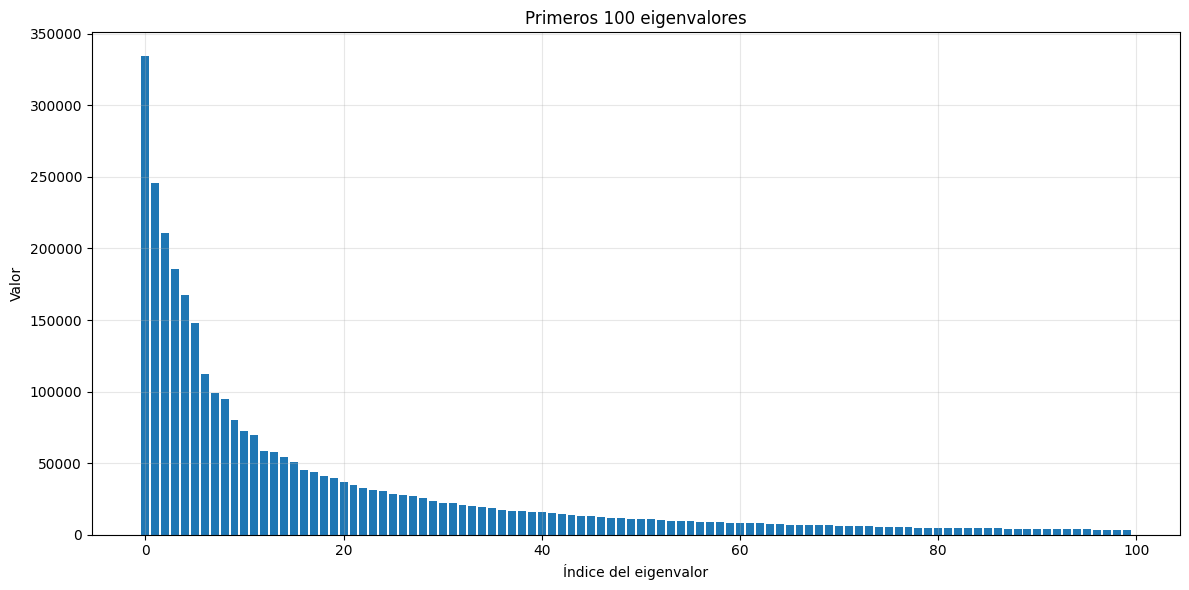

In [15]:
plt.figure(figsize=(12, 6))
n_values = 100
plt.bar(range(n_values), eigenvalues[:n_values])
plt.xlabel('Índice del eigenvalor')
plt.ylabel('Valor')
plt.title('Primeros {} eigenvalores'.format(n_values))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
total_var = np.sum(eigenvalues)
explained_variance_ratio = eigenvalues / total_var
cumulative_variance = np.cumsum(explained_variance_ratio)

In [17]:
ks= range(1, 200)
errors = pca_reconstruction_errors(X_img, X_centered, eigenvectors, X_mean, ks)

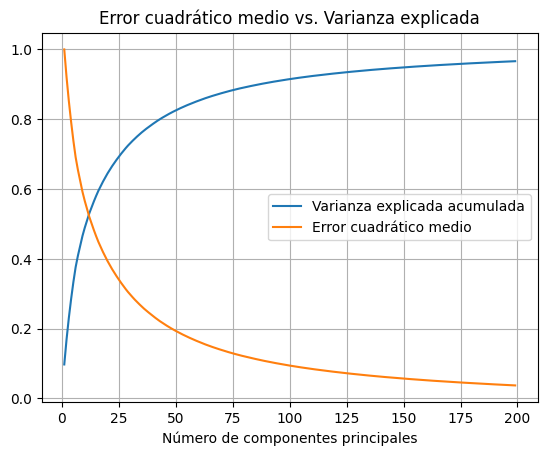

In [18]:
errors/= max(errors)  
ks = range(1, len(errors) + 1)

plt.plot(ks, cumulative_variance[:len(errors)], label='Varianza explicada acumulada')
plt.xlabel('Número de componentes principales')

plt.plot(ks, errors, label='Error cuadrático medio')
plt.xlabel("Número de componentes principales")

plt.title("Error cuadrático medio vs. Varianza explicada")
plt.grid(True)
plt.legend()
plt.show()

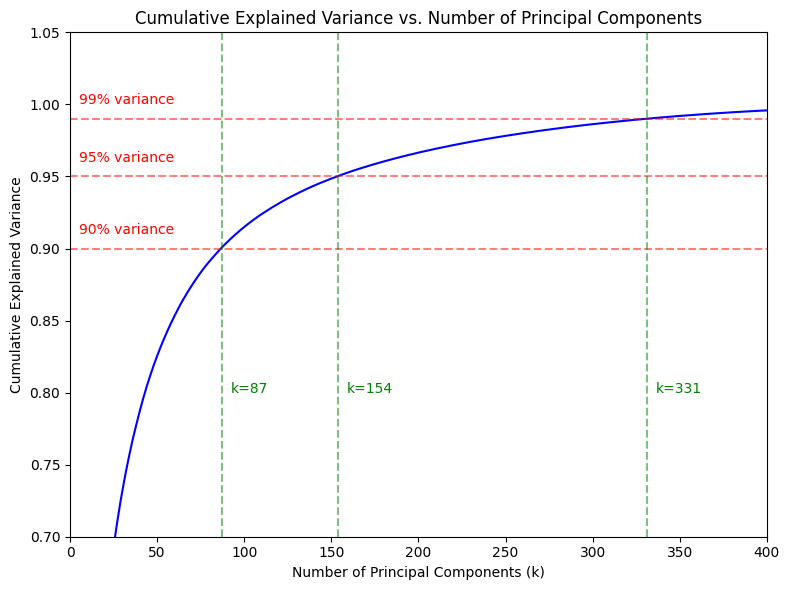

In [10]:
thresholds = [0.90, 0.95, 0.99]
k_values = {}

for threshold in thresholds:
    k_idx = np.argmax(cumulative_variance >= threshold)
    k_values[threshold] = k_idx + 1

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'b-')
plt.xlabel('Number of Principal Components (k)')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance vs. Number of Principal Components')

for threshold in thresholds:
    plt.axhline(y=threshold, color='r', linestyle='--', alpha=0.5)
    plt.text(5, threshold + 0.01, f'{int(threshold*100)}% variance', color='r')
    plt.axvline(x=k_values[threshold], color='g', linestyle='--', alpha=0.5)
    plt.text(k_values[threshold] + 5, 0.8, f'k={k_values[threshold]}', color='g')

plt.xlim(0, 400)
plt.ylim(0.7, 1.05)
plt.tight_layout()
plt.show()

### 2.b - Visualización de reconstrucciones

Seleccionamos una cantidad razonable de componentes y comparamos visualmente las imágenes originales y reconstruidas para una muestra de cada label del dataset.

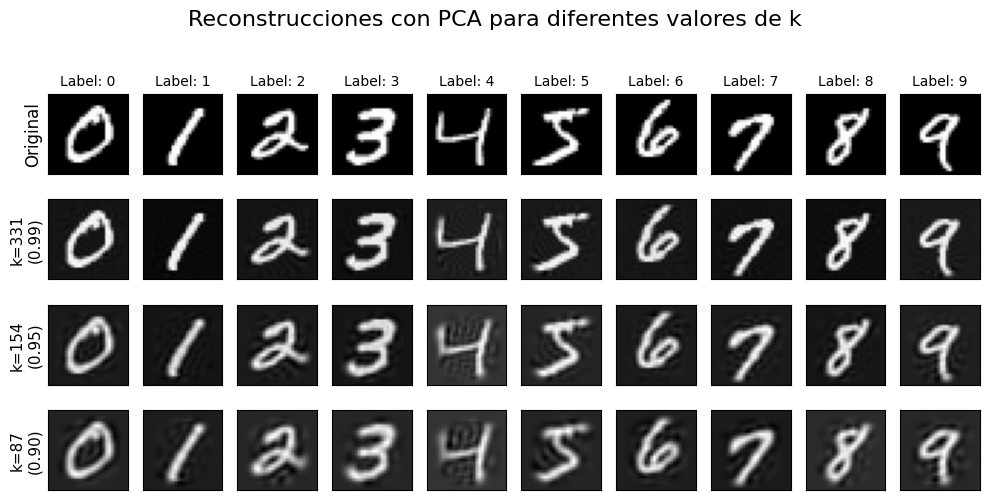

In [20]:
show_pca_reconstructions(X_img, X_centered, X_mean, eigenvectors, k_values, y)

### Visualización en 2D del MNIST con PCA

Reducimos la dimensionalidad del conjunto de datos MNIST a dos componentes principales utilizando PCA.  
Esta proyección permite visualizar cómo se agrupan los dígitos en un espacio bidimensional y evaluar visualmente si existen estructuras de cluster en los datos.

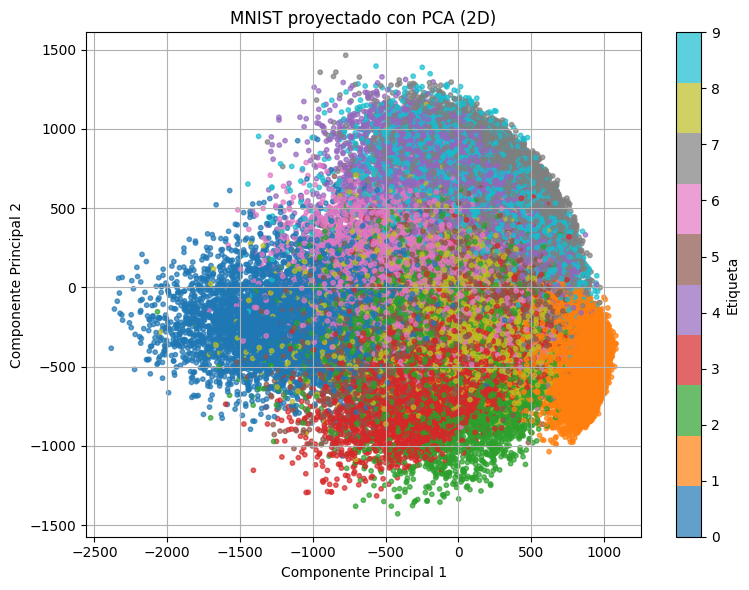

In [21]:
plot_pca_2d(X_centered, eigenvectors, y, title="MNIST proyectado con PCA (2D)")

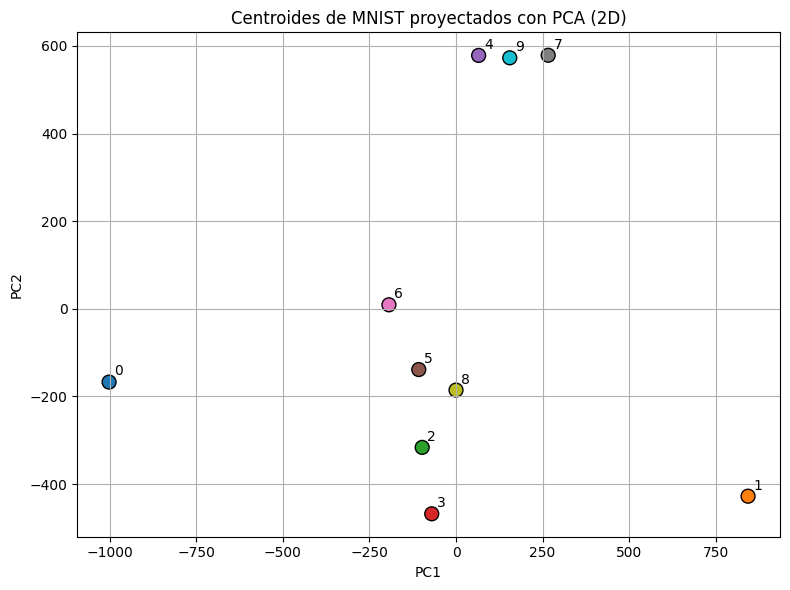

In [22]:
plot_pca_centroids_2d(X_centered, eigenvectors, y, title="Centroides de MNIST proyectados con PCA (2D)")

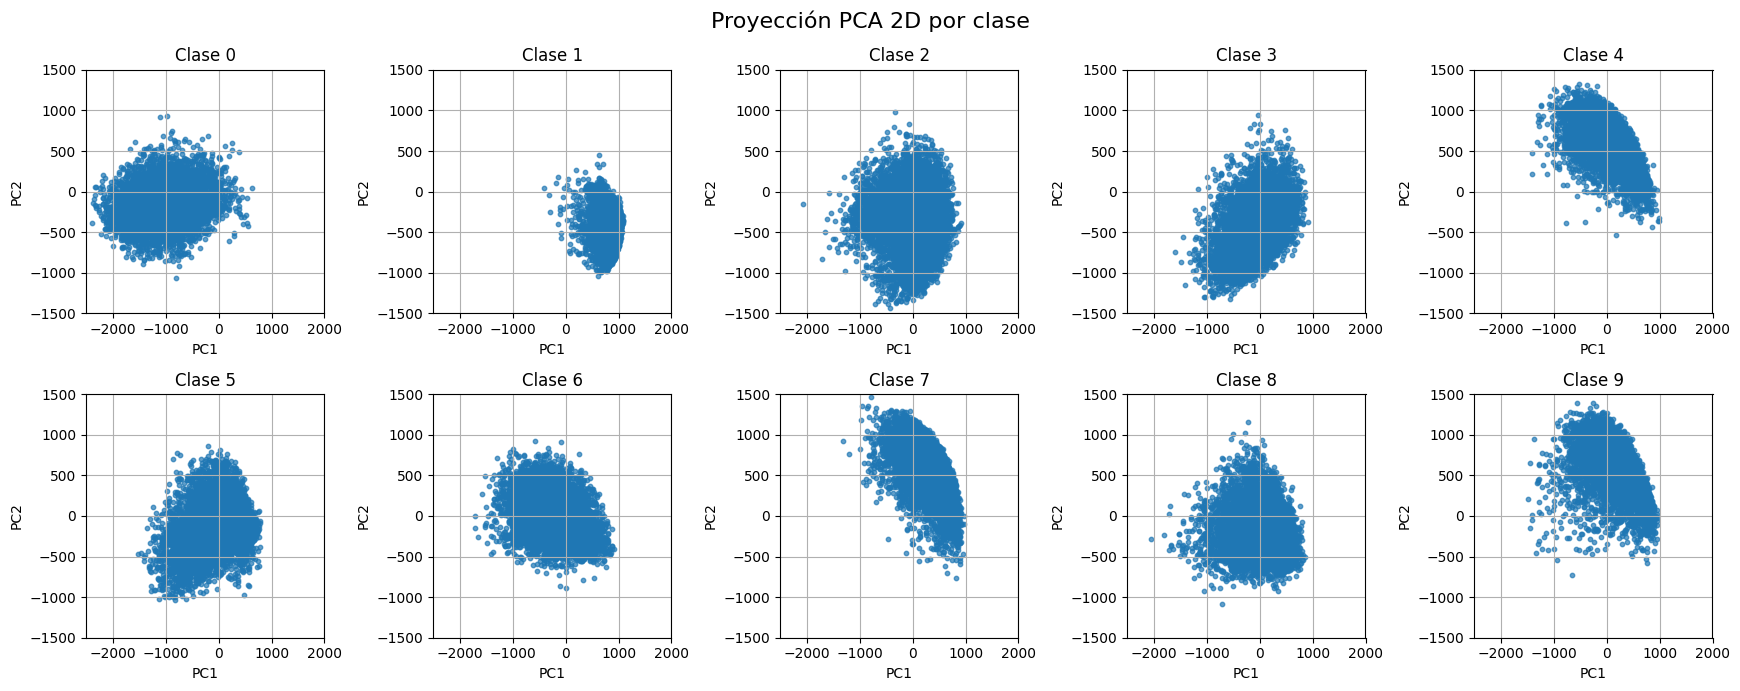

In [23]:
plot_pca_2d_per_class(X_centered, eigenvectors, y, title="Proyección PCA 2D por clase")

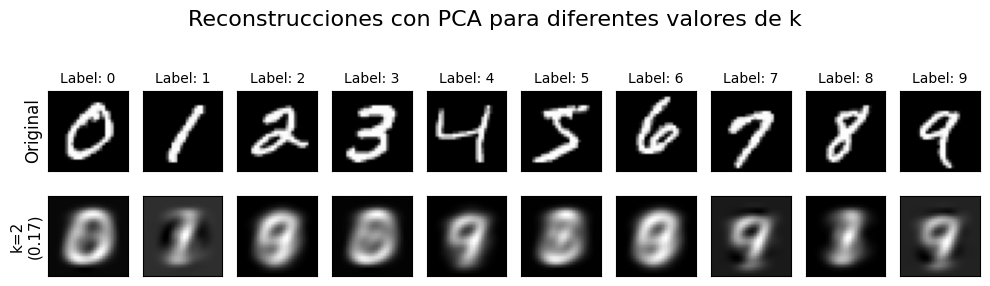

In [24]:
KS = {cumulative_variance[1]: 2}
show_pca_reconstructions(X_img, X_centered, X_mean, eigenvectors, KS, y)

## Clustering ++ Reduccion de dimencionalidad

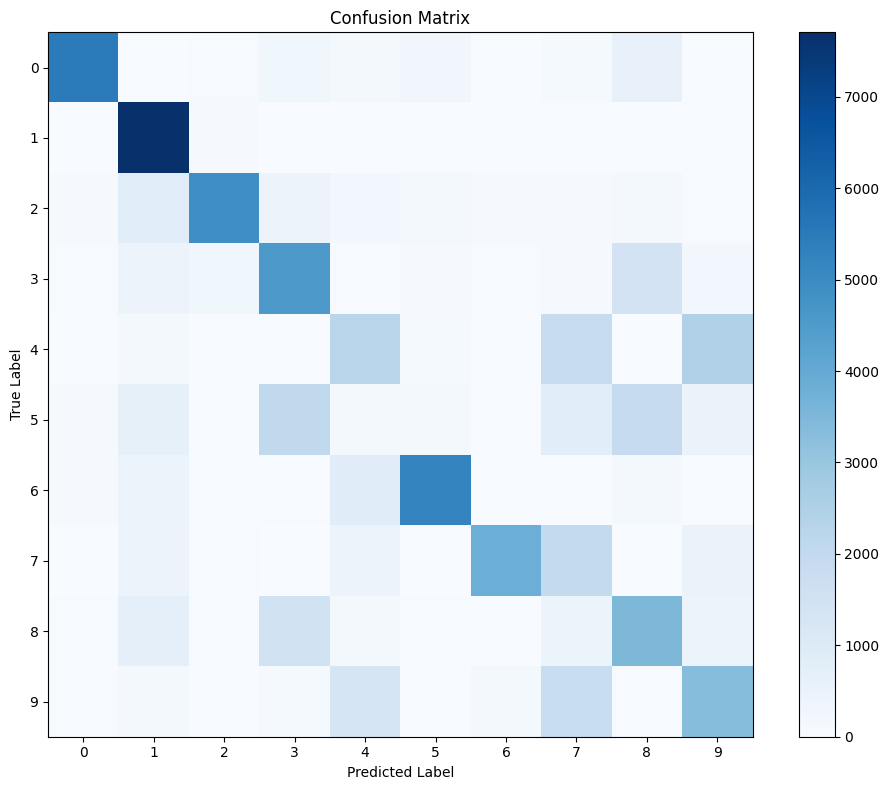

Precisión después de mapear clusters a dígitos: 0.6098


In [25]:
k_pca = k_values[0.90]
X_projected = project_data(X_centered, eigenvectors, k_pca)

kmeans_latent = KMeans(n_clusters=10, random_state=42)
kmeans_latent.fit(X_projected)
cluster_labels = kmeans_latent.predict(X_projected)

conf_matrix = custom_confusion_matrix(y, cluster_labels, n_classes=10)

cluster_to_digit = {}
for i in range(10):
    cluster_indices = np.where(cluster_labels == i)[0]
    if len(cluster_indices) > 0:
        most_common_digit = np.bincount(y[cluster_indices]).argmax()
        cluster_to_digit[i] = most_common_digit

orden_digitos = list(range(10))
orden_clusters = [cluster for _, cluster in sorted([(digit, cluster) for cluster, digit in cluster_to_digit.items()])]

reordered_conf_matrix = np.zeros((10, 10), dtype=int)
for i, digit in enumerate(orden_digitos):
    for j, cluster in enumerate(orden_clusters):
        reordered_conf_matrix[i, j] = conf_matrix[digit, cluster]

plot_confusion_matrix(reordered_conf_matrix, class_subset=None)

mapped_labels = np.array([cluster_to_digit.get(label, -1) for label in cluster_labels])
accuracy = np.sum(mapped_labels == y) / len(y)
print(f"Precisión después de mapear clusters a dígitos: {accuracy:.4f}")